# Sparsity studies (no charge)

In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
from scipy.optimize import curve_fit
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
jax.config.update('jax_enable_x64', True)

In [2]:
configs = {
    4: [
    '''
* *
 *
* *
 *
* *
    ''',
    '''
* *
 * *
* *
 * *
* *
    ''',
    '''
* * *
 * *
* * *
 * *
* * *
    ''',
    '''
* * *
 * * *
* * *
 * * *
* * *
    ''',
    '''
* * * *
 * * *
* * * *
 * * *
* * * *
    ''',
    '''
* * * *
 * * * *
* * * *
 * * * *
* * * *
    ''',
    '''
* * * * *
 * * * *
* * * * *
 * * * *
* * * * *
   '''
    ],
    6: [
    '''
* *
 *
* *
 *
* *
 *
* *
    ''',
    '''
* *
 * *
* *
 * *
* *
 * *
* *
    ''',
    '''
* * *
 * *
* * *
 * *
* * *
 * *
* * *
    ''',
    '''
* * *
 * * *
* * *
 * * *
* * *
 * * *
* * *
    '''
    ],
    8: [
    '''
* *
 *
* *
 *
* *
 *
* *
 *
* *
    ''',
    '''
* *
 * *
* *
 * *
* *
 * *
* *
 * *
* *
    ''',
    '''
* * *
 * *
* * *
 * *
* * *
 * *
* * *
 * *
* * *
    ''',
    ]
}
configs_all = sum(configs.values(), [])

template = '/data/iiyama/2dz2/sparsity_hstack/eigvecs_{}x{}_vacuum.h5'

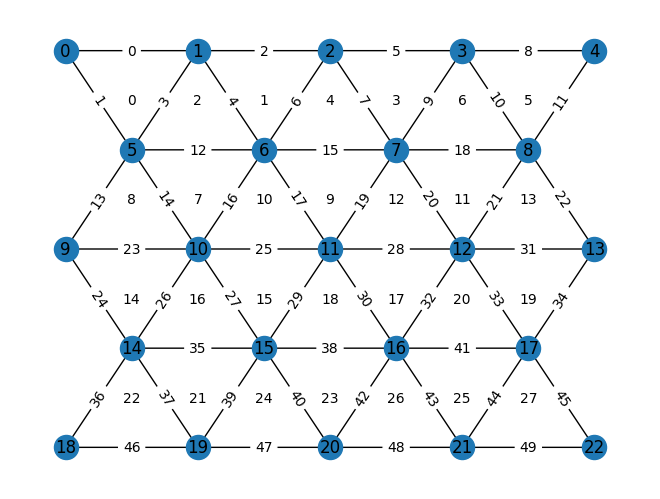

In [3]:
lattice = TriangularZ2Lattice(configs[4][6])
lattice.draw_graph();

In [4]:
for rows in [4, 6, 8]:
    for iconfig, config in enumerate(configs[rows]):
        cols = iconfig + 1
        lattice = TriangularZ2Lattice(config)
        nplaq = lattice.num_plaquettes
        filename = template.format(rows, cols)
        if not os.path.exists(filename):
            print(rows, cols)
            dual_lattice = lattice.plaquette_dual()
            hamiltonian = dual_lattice.make_hamiltonian(1.)
            hvec = make_hvec(hamiltonian, variable=True)

            @jax.jit
            def compute(xmat, plaquette_energy):
                # pylint: disable-next=unbalanced-tuple-unpacking
                vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T, plaquette_energy).T, xmat)
                return -vals[0], vecs[:, 0]

            lambdas = np.linspace(0., 4., 21)
            xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
            xmat[0, 0] = 1.

            with h5py.File(filename, 'w', libver='latest') as out:
                out.create_dataset('lambdas', data=lambdas)
                eigvals = out.create_dataset('eigval', shape=lambdas.shape, dtype=np.float64)
                eigvecs = out.create_dataset('eigvec', shape=lambdas.shape + (2 ** nplaq,), dtype=np.complex128)

                for ilmd, plaquette_energy in enumerate(lambdas):
                    val, vec = compute(xmat, plaquette_energy)
                    eigvals[ilmd] = val
                    eigvecs[ilmd] = vec


4 1


INFO:2025-12-19 10:49:51,713:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


4 2
4 3
4 4
4 5
4 6
4 7
6 1
6 2
6 3
6 4
8 1
8 2
8 3


### Probabilities in plaquette number sectors

In [19]:
rows, cols = 4, 6

config = configs[rows][cols - 1]
lattice = TriangularZ2Lattice(config)

nplaq = lattice.num_plaquettes
filename = template.format(rows, cols)
with h5py.File(filename, libver='latest') as source:
    lambdas = source['lambdas'][()]
    eigvecs = source['eigvec'][()]
probs = np.square(np.abs(eigvecs))

In [20]:
excitations = np.bitwise_count(np.arange(2 ** nplaq))
excitation_probs = [np.sort(probs[:, excitations == n]) for n in range(nplaq + 1)]
minima = np.stack([ep[:, 0] for ep in excitation_probs], axis=1)
maxima = np.stack([ep[:, -1] for ep in excitation_probs], axis=1)
median = np.stack([np.quantile(ep, 0.5, axis=1) for ep in excitation_probs], axis=1)
mean = np.stack([np.mean(ep, axis=1) for ep in excitation_probs], axis=1)

In [23]:
mean.shape

(21, 25)

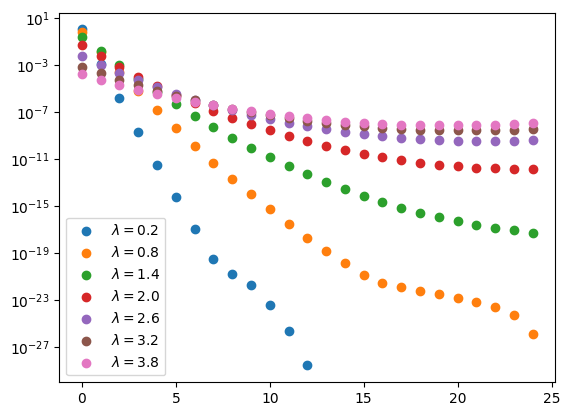

In [24]:
for il in range(1, lambdas.shape[0], 3):
    plt.scatter(np.arange(nplaq + 1), mean[il], label=fr'$\lambda={lambdas[il]:.1f}$')
plt.yscale('log')
plt.legend();

In [25]:
def line(x, a, b):
    return a * x + b

popt, _ = curve_fit(line, np.arange(9), np.log(mean[1, :9]), p0=(np.log(lambdas[1]), 0.))

In [26]:
popt

array([-6.16829523, -1.07552029])

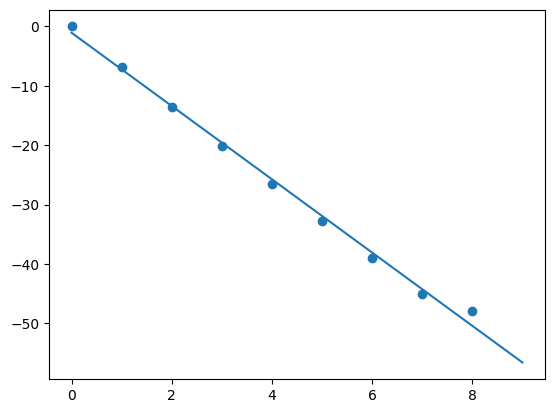

In [27]:
plt.scatter(np.arange(9), np.log(mean[1, :9]))
plt.plot(np.linspace(0., 9., 100), line(np.linspace(0., 9., 100), *popt))

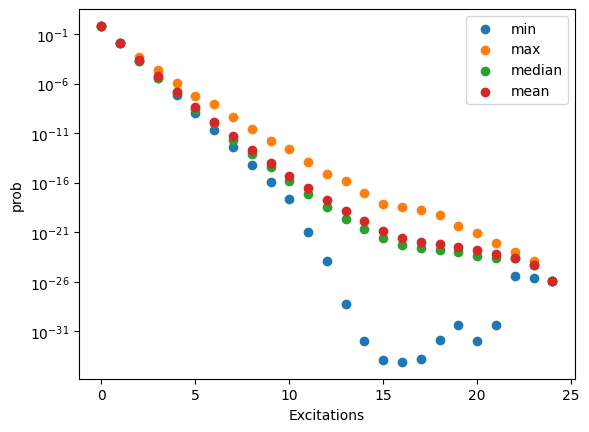

In [28]:
il = 4
x = np.arange(nplaq + 1)
plt.scatter(x, minima[il], label='min')
plt.scatter(x, maxima[il], label='max')
plt.scatter(x, median[il], label='median')
plt.scatter(x, mean[il], label='mean')
plt.yscale('log')
plt.xlabel('Excitations')
plt.ylabel('prob')
plt.legend();